In [1]:
#Import all libraries
import numpy as np # Math & statistics
import pandas as pd #File handling, reading datasets
import matplotlib.pyplot as plt #Data Visulization

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay


In [2]:
#Load the iris dataset
iris = load_iris() 

# Convert to a pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target # 0=Setosa, 1=Versicolor, 2=Virginica


In [3]:
print(df.shape)  # rows and columns

(150, 5)


In [4]:
print(df.head()) #Display First five rows

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [5]:
print(df['species'].value_counts()) #class distribution

species
0    50
1    50
2    50
Name: count, dtype: int64


In [6]:
print(df.describe()) #Dataset description

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [7]:
X = iris.data  # Features (the 4 measurements)
y = iris.target  # Labels (0, 1, 2)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,    # scaled features
    y,           # labels
    test_size=0.2,    # 20% for testing
    random_state=42,  # shuffle seed for reproducibility
    shuffle=True      # randomize before splitting
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 120
Testing samples: 30


In [10]:
# INSTANTIATE  Build the KNN model with K=5
model = KNeighborsClassifier(n_neighbors=5)

# FIT Train the model on training data
model.fit(X_train, y_train)

# PREDICT Make predictions on test data
predictions = model.predict(X_test)

print("Model trained successfully!")
print(f"Predictions: {predictions}")
print(f"Actual labels: {y_test}")

Model trained successfully!
Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [11]:
# Calculate F1 Score
f1 = f1_score(y_test, predictions, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"F1 Score (%): {f1 * 100:.2f}%")

F1 Score: 1.0000
F1 Score (%): 100.00%


In [12]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)
print()
print("Rows = Actual Class | Columns = Predicted Class")
print(f"Setosa:     {cm[0]}")
print(f"Versicolor: {cm[1]}")
print(f"Virginica:  {cm[2]}")

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Rows = Actual Class | Columns = Predicted Class
Setosa:     [10  0  0]
Versicolor: [0 9 0]
Virginica:  [ 0  0 11]


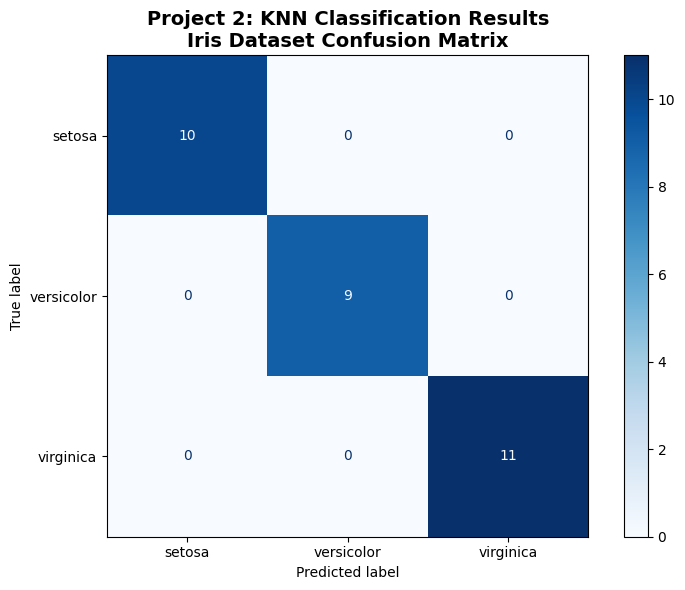


 Project 2 Complete!
 F1 Score: 100%
 Correct Predictions: 30/30
 False Alarms (FP): 0
 Missed Detections (FN): 0


In [13]:
# Visualize the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names  # Setosa, Versicolor, Virginica
)

disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Project 2: KNN Classification Results\nIris Dataset Confusion Matrix', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Project 2 Complete!")
print(f" F1 Score: 100%")
print(f" Correct Predictions: 30/30")
print(f" False Alarms (FP): 0")
print(f" Missed Detections (FN): 0")